## 2A. Define the modelling problem
Before writing modelling code, put a short Markdown section in the notebook explaining exactly what we're doing.
Question
Given the characteristics available for a job-market observation, can we predict whether its Automation_Risk is Low, Medium, or High?

This is a multiclass supervised classification problem.
We already know from Stage 1 that the target is approximately balanced:
- Low ≈ 32%
- Medium ≈ 35%
- High ≈ 34%



## 2B. Define predictors (X) and target (y)

The target variable is `Automation_Risk`, which contains the three classes
`Low`, `Medium`, and `High`.

The predictor matrix `X` will contain the job-market characteristics available
to the model at prediction time. The target variable itself must be excluded
from `X` to prevent target leakage.

Before defining the modelling variables, the Stage 1 cleaned dataset is loaded
and its columns are verified.

In [1]:
from pathlib import Path

import pandas as pd
import numpy as np

In [2]:
DATA_PATH = Path("../data/processed/features.csv")

df = pd.read_csv(DATA_PATH)

print(f"Shape: {df.shape}")
print("\nColumns:")
print(df.columns.tolist())

Shape: (500, 18)

Columns:
['Job_Title', 'Industry', 'Company_Size', 'Location', 'AI_Adoption_Level', 'Automation_Risk', 'Required_Skills', 'Salary_USD', 'Remote_Friendly', 'Job_Growth_Projection', 'ai_adoption_ord', 'company_size_ord', 'growth_ord', 'remote_flag', 'skill_exposure', 'ai_pressure', 'salary_pct_in_title', 'vulnerability_signal']


In [3]:
df.head()

,Job_Title,Industry,Company_Size,Location,AI_Adoption_Level,Automation_Risk,Required_Skills,Salary_USD,Remote_Friendly,Job_Growth_Projection,ai_adoption_ord,company_size_ord,growth_ord,remote_flag,skill_exposure,ai_pressure,salary_pct_in_title,vulnerability_signal
0,Cybersecurity Analyst,Entertainment,Small,Dubai,Medium,High,UX/UI Design,111392.165243,Yes,Growth,1,0,2,1,0.55,0.275,0.890909,0.000
1,Marketing Specialist,Technology,Large,Singapore,Medium,High,Marketing,93792.562466,No,Decline,1,2,0,0,0.65,0.325,0.520833,0.325
2,AI Researcher,Technology,Large,Singapore,Medium,High,UX/UI Design,107170.263069,Yes,Growth,1,2,2,1,0.55,0.275,0.784314,0.000
3,Sales Manager,Retail,Small,Berlin,Low,High,Project Management,93027.953758,No,Growth,0,0,2,0,0.35,0.000,0.530612,0.000
4,Cybersecurity Analyst,Entertainment,Small,Tokyo,Low,Low,JavaScript,87752.922171,Yes,Decline,0,0,0,1,0.80,0.000,0.490909,0.000


### Predictor selection

The primary supervised model uses only variables supplied in the original
hackathon dataset. Engineered variables in `features.csv` are excluded from the
core model so that model performance reflects predictive information contained
in the supplied data rather than assumptions introduced during feature
engineering.

`Automation_Risk` is the target and is excluded from the predictor matrix.

In [4]:
TARGET = "Automation_Risk"

FEATURES = [
    "Job_Title",
    "Industry",
    "Company_Size",
    "Location",
    "AI_Adoption_Level",
    "Required_Skills",
    "Salary_USD",
    "Remote_Friendly",
    "Job_Growth_Projection",
]

X = df[FEATURES].copy()
y = df[TARGET].copy()

print(f"X shape: {X.shape}")
print(f"y shape: {y.shape}")

print("\nTarget distribution:")
print(y.value_counts())

X shape: (500, 9)
y shape: (500,)

Target distribution:
Automation_Risk
Medium    173
High      169
Low       158
Name: count, dtype: int64


In [5]:
X.head()

,Job_Title,Industry,Company_Size,Location,AI_Adoption_Level,Required_Skills,Salary_USD,Remote_Friendly,Job_Growth_Projection
0,Cybersecurity Analyst,Entertainment,Small,Dubai,Medium,UX/UI Design,111392.165243,Yes,Growth
1,Marketing Specialist,Technology,Large,Singapore,Medium,Marketing,93792.562466,No,Decline
2,AI Researcher,Technology,Large,Singapore,Medium,UX/UI Design,107170.263069,Yes,Growth
3,Sales Manager,Retail,Small,Berlin,Low,Project Management,93027.953758,No,Growth
4,Cybersecurity Analyst,Entertainment,Small,Tokyo,Low,JavaScript,87752.922171,Yes,Decline


## 2C. Stratified train/test split

The dataset is divided into an 80% training set and a 20% held-out test set.

Stratification by `Automation_Risk` preserves approximately the same
Low/Medium/High class distribution in both subsets.

The training set will be used for preprocessing, model fitting, and
cross-validation. The test set will remain untouched until final model
evaluation.

In [6]:
from sklearn.model_selection import train_test_split

In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    stratify=y,
    random_state=42,  # Give me the same random split again when this code is rerun.
)

In [8]:
# verify sizes

print(f"X_train: {X_train.shape}")
print(f"X_test:  {X_test.shape}")
print(f"y_train: {y_train.shape}")
print(f"y_test:  {y_test.shape}")

X_train: (400, 9)
X_test:  (100, 9)
y_train: (400,)
y_test:  (100,)


In [9]:
# verify the class proportions were preserrved

split_distribution = pd.DataFrame(
    {
        "Full dataset": y.value_counts(normalize=True),
        "Training set": y_train.value_counts(normalize=True),
        "Test set": y_test.value_counts(normalize=True),
    }
)

split_distribution.round(3)

,Full dataset,Training set,Test set
Automation_Risk,,,
Medium,0.346,0.345,0.35
High,0.338,0.338,0.34
Low,0.316,0.318,0.31


## 2D. Build the preprocessing pipeline

The predictors contain eight categorical variables and one continuous numeric
variable (`Salary_USD`).

Categorical predictors are transformed using one-hot encoding so that the
models can use them without imposing artificial numeric distances between
categories.

`Salary_USD` is retained as a numeric predictor. Preprocessing is defined using
a `ColumnTransformer`, allowing categorical and numeric variables to be handled
separately within a reproducible modelling pipeline.

The preprocessor will be fitted only on the training data to prevent information
from the held-out test set leaking into model development.

In [10]:
# identify column types

categorical_features = [
    "Job_Title",
    "Industry",
    "Company_Size",
    "Location",
    "AI_Adoption_Level",
    "Required_Skills",
    "Remote_Friendly",
    "Job_Growth_Projection",
]

numeric_features = [
    "Salary_USD",
]

print(f"Categorical features: {len(categorical_features)}")
print(f"Numeric features: {len(numeric_features)}")
print(f"Total features: {len(categorical_features) + len(numeric_features)}")

Categorical features: 8
Numeric features: 1
Total features: 9


In [11]:
# Import the preprocessing tools
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

In [12]:
# create categorical transformer

OneHotEncoder(handle_unknown="ignore")

,"handle_unknown handle_unknown: {'error', 'ignore', 'infrequent_if_exist', 'warn'}, default='error'Specifies the way unknown categories are handled during :meth:`transform`.- 'error' : Raise an error if an unknown category is present during transform.- 'ignore' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will be all zeros. In the inverse transform, an unknown category will be denoted as None.- 'infrequent_if_exist' : When an unknown category is encountered during transform, the resulting one-hot encoded columns for this feature will map to the infrequent category if it exists. The infrequent category will be mapped to the last position in the encoding. During inverse transform, an unknown category will be mapped to the category denoted `'infrequent'` if it exists. If the `'infrequent'` category does not exist, then :meth:`transform` and :meth:`inverse_transform` will handle an unknown category as with `handle_unknown='ignore'`. Infrequent categories exist based on `min_frequency` and `max_categories`. Read more in the :ref:`User Guide <encoder_infrequent_categories>`.- 'warn' : When an unknown category is encountered during transform a warning is issued, and the encoding then proceeds as described for `handle_unknown=""infrequent_if_exist""`... versionchanged:: 1.1 `'infrequent_if_exist'` was added to automatically handle unknown categories and infrequent categories... versionadded:: 1.6 The option `""warn""` was added in 1.6.",'ignore'
,"categories categories: 'auto' or a list of array-like, default='auto'Categories (unique values) per feature:- 'auto' : Determine categories automatically from the training data.- list : ``categories[i]`` holds the categories expected in the ith column. The passed categories should not mix strings and numeric values within a single feature, and should be sorted in case of numeric values.The used categories can be found in the ``categories_`` attribute... versionadded:: 0.20",'auto'
,"drop drop: {'first', 'if_binary'} or an array-like of shape (n_features,), default=NoneSpecifies a methodology to use to drop one of the categories perfeature. This is useful in situations where perfectly collinearfeatures cause problems, such as when feeding the resulting datainto an unregularized linear regression model.However, dropping one category breaks the symmetry of the originalrepresentation and can therefore induce a bias in downstream models,for instance for penalized linear classification or regression models.- None : retain all features (the default).- 'first' : drop the first category in each feature. If only one category is present, the feature will be dropped entirely.- 'if_binary' : drop the first category in each feature with two categories. Features with 1 or more than 2 categories are left intact.- array : ``drop[i]`` is the category in feature ``X[:, i]`` that should be dropped.When `max_categories` or `min_frequency` is configured to groupinfrequent categories, the dropping behavior is handled after thegrouping... versionadded:: 0.21 The parameter `drop` was added in 0.21... versionchanged:: 0.23 The option `drop='if_binary'` was added in 0.23... versionchanged:: 1.1 Support for dropping infrequent categories.",None
,"sparse_output sparse_output: bool, default=TrueWhen ``True``, it returns a SciPy sparse matrix/arrayin ""Compressed Sparse Row"" (CSR) format... versionadded:: 1.2 `sparse` was renamed to `sparse_output`",True
,"dtype dtype: number type, default=np.float64Desired dtype of output.",<class 'numpy.float64'>
,"min_frequency min_frequency: int or float, default=NoneSpecifies the minimum frequency below which a category will beconsidered infrequent.- If `int`, categories with a smaller cardinality will be considered infrequent.- If `float`, categories with a smaller cardinality than `min_frequency * n_samples` will be considered infrequent... versionadded:: 1.1 Read more in the :ref:`User Guide <encoder_infrequen

In [13]:
# create the ColumnTransformer

preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
        (
            "numeric",
            "passthrough",
            numeric_features,
        ),
    ]
)

In [14]:
# a small validation check

selected_features = categorical_features + numeric_features

print("Features in X but not preprocessing lists:")
print(set(X_train.columns) - set(selected_features))

print("\nFeatures in preprocessing lists but not X:")
print(set(selected_features) - set(X_train.columns))

Features in X but not preprocessing lists:
set()

Features in preprocessing lists but not X:
set()


## 2E. Establish a naive baseline

A `DummyClassifier` is used to establish the minimum predictive performance
that subsequent machine-learning models should improve upon.

The baseline uses the `most_frequent` strategy, which always predicts the most
common `Automation_Risk` class observed in the training data. It therefore
does not learn relationships between the predictors and the target.

Baseline performance is evaluated using stratified 5-fold cross-validation on
the training set. Accuracy and macro-averaged F1 are recorded for comparison
with subsequent models.

In [15]:
from sklearn.dummy import DummyClassifier
from sklearn.pipeline import Pipeline
from sklearn.model_selection import StratifiedKFold, cross_validate

In [16]:
# Define cross-validation strategy

cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=42,
)

In [17]:
# Dummy pipeline

dummy_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        ("classifier", DummyClassifier(strategy="most_frequent")),
    ]
)

In [18]:
# Define evaluation metrics

scoring = {
    "accuracy": "accuracy",  # Of all predictions, what proportion were correct?
    "macro_f1": "f1_macro",  # How well are we performing across Low, Medium and High when each class gets equal importance?
}

In [19]:
# 5-fold cross-validation
dummy_cv = cross_validate(
    estimator=dummy_pipeline,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=scoring,
)

In [20]:
# the results

print("Fold accuracies:")
print(dummy_cv["test_accuracy"])

print("\nFold macro-F1 scores:")
print(dummy_cv["test_macro_f1"])

Fold accuracies:
[0.3375 0.3375 0.35   0.35   0.35  ]

Fold macro-F1 scores:
[0.1682243  0.1682243  0.17283951 0.17283951 0.17283951]


In [21]:
# summary of baseline

dummy_accuracy_mean = dummy_cv["test_accuracy"].mean()
dummy_accuracy_sd = dummy_cv["test_accuracy"].std()

dummy_f1_mean = dummy_cv["test_macro_f1"].mean()
dummy_f1_sd = dummy_cv["test_macro_f1"].std()

print(f"Dummy CV accuracy: " f"{dummy_accuracy_mean:.3f} ± {dummy_accuracy_sd:.3f}")

print(f"Dummy CV macro-F1: " f"{dummy_f1_mean:.3f} ± {dummy_f1_sd:.3f}")

Dummy CV accuracy: 0.345 ± 0.006
Dummy CV macro-F1: 0.171 ± 0.002


### Baseline result

The most-frequent-class baseline achieved a mean cross-validated accuracy of
**0.345 ± 0.006** and macro-F1 of **0.171 ± 0.002**.

The accuracy reflects the approximately balanced three-class target: predicting
only the most common class correctly classifies roughly one-third of observations.
The substantially lower macro-F1 reflects the model's failure to identify the
other risk classes.

Subsequent models should therefore demonstrate improvement over this baseline,
particularly in macro-F1, to provide evidence of useful predictive signal.

#### 2F. Logistic Regression


In [22]:
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression

In [23]:
logistic_preprocessor = ColumnTransformer(
    transformers=[
        (
            "categorical",
            OneHotEncoder(handle_unknown="ignore"),
            categorical_features,
        ),
        (
            "numeric",
            StandardScaler(),
            numeric_features,
        ),
    ]
)

In [24]:
logistic_pipeline = Pipeline(
    steps=[
        ("preprocessor", logistic_preprocessor),
        (
            "classifier",
            LogisticRegression(
                max_iter=1000,
                random_state=42,
            ),
        ),
    ]
)

In [25]:
# Cross-validate it exactly like the Dummy

logistic_cv = cross_validate(
    estimator=logistic_pipeline,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=scoring,
)

In [26]:
print("Fold accuracies:")
print(logistic_cv["test_accuracy"])

print("\nFold macro-F1 scores:")
print(logistic_cv["test_macro_f1"])

Fold accuracies:
[0.3375 0.325  0.3    0.425  0.4125]

Fold macro-F1 scores:
[0.33734733 0.31750842 0.3        0.41999059 0.41391941]


In [27]:
logistic_accuracy_mean = logistic_cv["test_accuracy"].mean()
logistic_accuracy_sd = logistic_cv["test_accuracy"].std()

logistic_f1_mean = logistic_cv["test_macro_f1"].mean()
logistic_f1_sd = logistic_cv["test_macro_f1"].std()

print(
    f"Logistic Regression CV accuracy: "
    f"{logistic_accuracy_mean:.3f} ± {logistic_accuracy_sd:.3f}"
)

print(
    f"Logistic Regression CV macro-F1: "
    f"{logistic_f1_mean:.3f} ± {logistic_f1_sd:.3f}"
)

Logistic Regression CV accuracy: 0.360 ± 0.050
Logistic Regression CV macro-F1: 0.358 ± 0.050


### Logistic Regression result

Logistic Regression achieved a mean cross-validated accuracy of
**0.360 ± 0.050** and macro-F1 of **0.358 ± 0.050**.

Compared with the most-frequent baseline (accuracy = 0.345; macro-F1 = 0.171),
the model produced only a small improvement in overall accuracy, although
macro-F1 increased substantially because Logistic Regression attempts to
distinguish among all three risk classes rather than predicting only the
majority class.

Performance also varied across folds, with accuracy ranging from 0.300 to
0.425. At this stage, the results do not provide strong evidence that the
supplied predictors contain substantial predictive signal for
`Automation_Risk`.

Tree-based models will next be evaluated to determine whether nonlinear
relationships or interactions among predictors provide additional predictive
information.

## 2G. Random Forest

A Random Forest classifier is evaluated as a nonlinear tree-based alternative
to Logistic Regression.

Unlike Logistic Regression, Random Forest can capture nonlinear relationships
and interactions among predictors without requiring those relationships to be
specified in advance.

The model is evaluated using the same stratified 5-fold cross-validation
strategy and the same accuracy and macro-F1 metrics used for the baseline and
Logistic Regression.

In [28]:
from sklearn.ensemble import RandomForestClassifier

In [29]:
random_forest_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=300,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

In [30]:
random_forest_cv = cross_validate(
    estimator=random_forest_pipeline,
    X=X_train,
    y=y_train,
    cv=cv,
    scoring=scoring,
)

In [31]:
print("Fold accuracies:")
print(random_forest_cv["test_accuracy"])

print("\nFold macro-F1 scores:")
print(random_forest_cv["test_macro_f1"])

Fold accuracies:
[0.35   0.3375 0.3375 0.45   0.3625]

Fold macro-F1 scores:
[0.35111968 0.33223029 0.33571429 0.41031312 0.36221506]


In [32]:
rf_accuracy_mean = random_forest_cv["test_accuracy"].mean()
rf_accuracy_sd = random_forest_cv["test_accuracy"].std()

rf_f1_mean = random_forest_cv["test_macro_f1"].mean()
rf_f1_sd = random_forest_cv["test_macro_f1"].std()

print(f"Random Forest CV accuracy: " f"{rf_accuracy_mean:.3f} ± {rf_accuracy_sd:.3f}")

print(f"Random Forest CV macro-F1: " f"{rf_f1_mean:.3f} ± {rf_f1_sd:.3f}")

Random Forest CV accuracy: 0.367 ± 0.042
Random Forest CV macro-F1: 0.358 ± 0.028


### Random Forest result

Random Forest achieved a mean cross-validated accuracy of **0.367 ± 0.042**
and macro-F1 of **0.358 ± 0.028**.

This represents only a small improvement in mean accuracy over the
most-frequent baseline (0.345) and Logistic Regression (0.360). Its macro-F1
was effectively identical to Logistic Regression (0.358).

The nonlinear Random Forest therefore did not produce a substantial
improvement over the simpler linear model. This is consistent with the Stage 1
finding that the supplied predictors contain little detectable association
with `Automation_Risk`.

A boosting model will be evaluated next to test whether a different nonlinear
learning strategy identifies additional predictive signal.

In [33]:
import xgboost

print(xgboost.__version__)

3.4.1


## 2H. XGBoost

XGBoost is evaluated as a gradient-boosted tree model to determine whether a
sequential boosting approach can identify predictive structure not captured by
Logistic Regression or Random Forest.

The model is evaluated using the same stratified 5-fold cross-validation
strategy and the same accuracy and macro-F1 metrics used for all previous
models. This ensures that model performance is directly comparable.

In [34]:
# Import XGBoost and a label encoder
from xgboost import XGBClassifier
from sklearn.preprocessing import LabelEncoder

In [35]:
label_encoder = LabelEncoder()

y_train_xgb = label_encoder.fit_transform(y_train)

print("Original classes:", label_encoder.classes_)
print("Encoded classes:", np.unique(y_train_xgb))

Original classes: ['High' 'Low' 'Medium']
Encoded classes: [0 1 2]


In [36]:
xgb_pipeline = Pipeline(
    steps=[
        ("preprocessor", preprocessor),
        (
            "classifier",
            XGBClassifier(
                objective="multi:softprob",
                eval_metric="mlogloss",
                n_estimators=300,
                learning_rate=0.05,
                max_depth=3,
                random_state=42,
                n_jobs=-1,
            ),
        ),
    ]
)

In [37]:
xgb_cv = cross_validate(
    estimator=xgb_pipeline,
    X=X_train,
    y=y_train_xgb,
    cv=cv,
    scoring=scoring,
)

In [38]:
print("Fold accuracies:")
print(xgb_cv["test_accuracy"])

print("\nFold macro-F1 scores:")
print(xgb_cv["test_macro_f1"])

Fold accuracies:
[0.325  0.2875 0.3    0.375  0.35  ]

Fold macro-F1 scores:
[0.32589209 0.28154488 0.29021572 0.35432844 0.34642401]


In [39]:
xgb_accuracy_mean = xgb_cv["test_accuracy"].mean()
xgb_accuracy_sd = xgb_cv["test_accuracy"].std()

xgb_f1_mean = xgb_cv["test_macro_f1"].mean()
xgb_f1_sd = xgb_cv["test_macro_f1"].std()

print(f"XGBoost CV accuracy: " f"{xgb_accuracy_mean:.3f} ± {xgb_accuracy_sd:.3f}")

print(f"XGBoost CV macro-F1: " f"{xgb_f1_mean:.3f} ± {xgb_f1_sd:.3f}")

XGBoost CV accuracy: 0.328 ± 0.032
XGBoost CV macro-F1: 0.320 ± 0.029


### XGBoost result

XGBoost achieved a mean cross-validated accuracy of **0.328 ± 0.032** and
macro-F1 of **0.320 ± 0.029**.

Its mean accuracy was below the most-frequent baseline (0.345), while both
accuracy and macro-F1 were lower than those obtained by Logistic Regression
and Random Forest.

The boosted nonlinear model therefore did not identify additional predictive
structure in the supplied predictors. Together with the Logistic Regression
and Random Forest results, this strengthens the evidence that the supplied
features contain limited signal for predicting `Automation_Risk`.

## 2I. Model comparison

Candidate models are compared using mean stratified 5-fold cross-validation
performance on the training set. Accuracy measures overall classification
performance, while macro-F1 gives equal weight to performance across the
Low, Medium, and High risk classes.

Model selection considers both predictive performance and stability rather
than choosing a model solely because it is more complex.

In [40]:
model_comparison = pd.DataFrame(
    {
        "Model": [
            "Dummy (most frequent)",
            "Logistic Regression",
            "Random Forest",
            "XGBoost",
        ],
        "CV Accuracy": [
            dummy_accuracy_mean,
            logistic_accuracy_mean,
            rf_accuracy_mean,
            xgb_accuracy_mean,
        ],
        "Accuracy SD": [
            dummy_accuracy_sd,
            logistic_accuracy_sd,
            rf_accuracy_sd,
            xgb_accuracy_sd,
        ],
        "CV Macro-F1": [
            dummy_f1_mean,
            logistic_f1_mean,
            rf_f1_mean,
            xgb_f1_mean,
        ],
        "Macro-F1 SD": [
            dummy_f1_sd,
            logistic_f1_sd,
            rf_f1_sd,
            xgb_f1_sd,
        ],
    }
)

model_comparison.round(3)

,Model,CV Accuracy,Accuracy SD,CV Macro-F1,Macro-F1 SD
0,Dummy (most frequent),0.345,0.006,0.171,0.002
1,Logistic Regression,0.360,0.050,0.358,0.050
2,Random Forest,0.368,0.042,0.358,0.028
3,XGBoost,0.328,0.032,0.320,0.029


### Model comparison interpretation

Across the candidate models, predictive performance remained close to the
approximately one-third accuracy expected in this balanced three-class
classification problem.

Random Forest produced the highest mean cross-validated accuracy (0.367), but
this represented only a small absolute improvement over the most-frequent
baseline (0.345). Logistic Regression and Random Forest produced essentially
identical macro-F1 scores (0.358), while XGBoost did not improve performance
and achieved accuracy below the baseline.

Increasing model complexity therefore did not produce a substantial or
consistent improvement in predictive performance. These results are consistent
with the Stage 1 association analysis, which found little evidence of
relationships between the supplied predictors and `Automation_Risk`.

The current evidence suggests that the supplied dataset contains insufficient
predictive signal to support a reliable role-level automation-risk classifier.

## 2J. Held-out test evaluation

Random Forest is selected as the candidate for final evaluation because it
produced the highest mean cross-validated accuracy (0.367) while achieving
macro-F1 comparable to Logistic Regression.

The complete Random Forest pipeline is now fitted to all 400 training
observations and evaluated once on the 100-observation held-out test set.

The test set has not been used during preprocessing, model fitting,
cross-validation, or model selection. It therefore provides an independent
estimate of final model performance.

In [41]:
random_forest_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('preprocessor', ...), ('classifier', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['High','Low','Medium']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](9,)","['Job_Title','Industry','Company_Size',...,'Salary_USD','Remote_Friendly', 'Job_Growth_Projection']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,9
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('categorical', ...), ('numeric', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default 

In [42]:
y_pred = random_forest_pipeline.predict(X_test)

In [43]:
from sklearn.metrics import accuracy_score, f1_score

In [44]:
test_accuracy = accuracy_score(y_test, y_pred)
test_macro_f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
)

print(f"Test accuracy: {test_accuracy:.3f}")
print(f"Test macro-F1: {test_macro_f1:.3f}")

Test accuracy: 0.350
Test macro-F1: 0.344


In [45]:
# How did Random Forest perform separately for Low, Medium and High?
from sklearn.metrics import classification_report

In [46]:
print(
    classification_report(
        y_test,
        y_pred,
        digits=3,
    )
)

              precision    recall  f1-score   support

        High      0.306     0.324     0.314        34
         Low      0.320     0.258     0.286        31
      Medium      0.410     0.457     0.432        35

    accuracy                          0.350       100
   macro avg      0.345     0.346     0.344       100
weighted avg      0.347     0.350     0.347       100



In [47]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

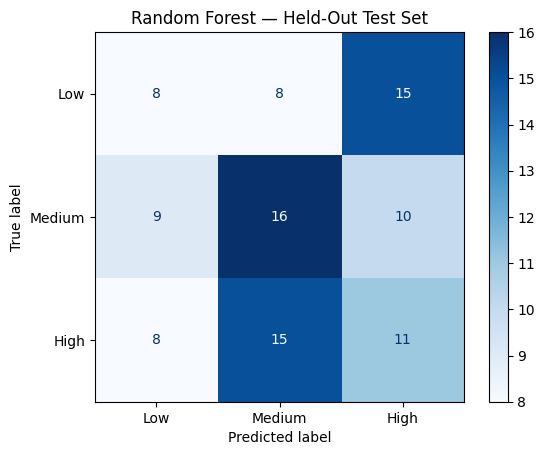

In [48]:
ConfusionMatrixDisplay.from_predictions(
    y_test,
    y_pred,
    labels=["Low", "Medium", "High"],
    cmap="Blues",
)

plt.title("Random Forest — Held-Out Test Set")
plt.show()

In [49]:
final_evaluation = pd.DataFrame(
    {
        "Metric": ["Accuracy", "Macro-F1"],
        "Cross-validation": [
            rf_accuracy_mean,
            rf_f1_mean,
        ],
        "Held-out test": [
            test_accuracy,
            test_macro_f1,
        ],
    }
)

final_evaluation.round(3)

,Metric,Cross-validation,Held-out test
0,Accuracy,0.368,0.350
1,Macro-F1,0.358,0.344


### Held-out test interpretation

On the 100-observation held-out test set, Random Forest achieved an accuracy of
**0.350** and macro-F1 of **0.344**.

These results are slightly below its cross-validated performance
(accuracy = 0.368; macro-F1 = 0.358) and place held-out accuracy essentially
at the level of the naive majority-class benchmark.

The confusion matrix shows substantial misclassification across all three risk
classes. Only 8 of 31 Low-risk observations, 16 of 35 Medium-risk observations,
and 11 of 34 High-risk observations were correctly classified. Notably, 15 of
the 31 actual Low-risk observations were classified as High risk.

The held-out evaluation therefore provides no evidence that the small
cross-validation advantage of Random Forest translates into practically useful
generalisation to unseen observations.

In [50]:
from sklearn.metrics import classification_report

class_report = classification_report(
    y_test,
    y_pred,
    output_dict=True,
)

class_metrics = pd.DataFrame(class_report).T.loc[
    ["Low", "Medium", "High"], ["precision", "recall", "f1-score", "support"]
]

class_metrics.round(3)

,precision,recall,f1-score,support
Low,0.320,0.258,0.286,31.0
Medium,0.410,0.457,0.432,35.0
High,0.306,0.324,0.314,34.0


## 2K. Error analysis

Performance was weak across all three risk classes rather than being driven by
failure on only one class.

The model identified fewer than half of the observations belonging to each
risk category. Low-risk observations were particularly difficult to identify,
and substantial confusion occurred between the Low and High categories.

The error pattern therefore does not indicate that the model reliably
separates the three automation-risk levels.

## 2L. Model explanation

To examine how the selected Random Forest generated its predictions, feature
importance is inspected for the fitted model.

These importances describe which encoded predictors the Random Forest relied
upon most when constructing its decision trees. They should not be interpreted
as causal effects or as evidence that the corresponding variables are reliable
real-world drivers of automation risk.

This distinction is especially important because the model demonstrated weak
held-out predictive performance.

In [51]:
fitted_preprocessor = random_forest_pipeline.named_steps["preprocessor"]
fitted_rf = random_forest_pipeline.named_steps["classifier"]

In [52]:
feature_names = fitted_preprocessor.get_feature_names_out()

print(f"Number of transformed features: {len(feature_names)}")
print(feature_names)

Number of transformed features: 52
['categorical__Job_Title_AI Researcher'
 'categorical__Job_Title_Cybersecurity Analyst'
 'categorical__Job_Title_Data Scientist'
 'categorical__Job_Title_HR Manager'
 'categorical__Job_Title_Marketing Specialist'
 'categorical__Job_Title_Operations Manager'
 'categorical__Job_Title_Product Manager'
 'categorical__Job_Title_Sales Manager'
 'categorical__Job_Title_Software Engineer'
 'categorical__Job_Title_UX Designer' 'categorical__Industry_Education'
 'categorical__Industry_Energy' 'categorical__Industry_Entertainment'
 'categorical__Industry_Finance' 'categorical__Industry_Healthcare'
 'categorical__Industry_Manufacturing' 'categorical__Industry_Retail'
 'categorical__Industry_Technology'
 'categorical__Industry_Telecommunications'
 'categorical__Industry_Transportation' 'categorical__Company_Size_Large'
 'categorical__Company_Size_Medium' 'categorical__Company_Size_Small'
 'categorical__Location_Berlin' 'categorical__Location_Dubai'
 'categorical__

In [53]:
feature_importances = fitted_rf.feature_importances_

print(f"Number of feature names: {len(feature_names)}")
print(f"Number of importances: {len(feature_importances)}")

Number of feature names: 52
Number of importances: 52


In [54]:
importance_df = pd.DataFrame(
    {
        "Feature": feature_names,
        "Importance": feature_importances,
    }
)

importance_df = importance_df.sort_values(
    "Importance",
    ascending=False,
)

importance_df.head(15)

,Feature,Importance
51,numeric__Salary_USD,0.130683
34,categorical__AI_Adoption_Level_Low,0.024025
35,categorical__AI_Adoption_Level_Medium,0.023846
48,categorical__Job_Growth_Projection_Decline,0.023674
33,categorical__AI_Adoption_Level_High,0.023191
46,categorical__Remote_Friendly_No,0.023163
50,categorical__Job_Growth_Projection_Stable,0.022763
21,categorical__Company_Size_Medium,0.022688
20,categorical__Company_Size_Large,0.022471
22,categorical__Company_Size_Small,0.022279


In [55]:
def original_feature_name(encoded_name):
    name = encoded_name.split("__", 1)[-1]

    for feature in categorical_features:
        if name.startswith(f"{feature}_"):
            return feature

    return name


importance_df["Original_Feature"] = importance_df["Feature"].apply(
    original_feature_name
)

In [56]:
aggregated_importance = (
    importance_df.groupby("Original_Feature", as_index=False)["Importance"]
    .sum()
    .sort_values("Importance", ascending=False)
)

aggregated_importance

,Original_Feature,Importance
5,Location,0.157845
2,Industry,0.157082
7,Required_Skills,0.151797
4,Job_Title,0.151647
8,Salary_USD,0.130683
0,AI_Adoption_Level,0.071062
3,Job_Growth_Projection,0.068239
1,Company_Size,0.067439
6,Remote_Friendly,0.044207


In [57]:
print(f"Original predictors represented: {len(aggregated_importance)}")

Original predictors represented: 9


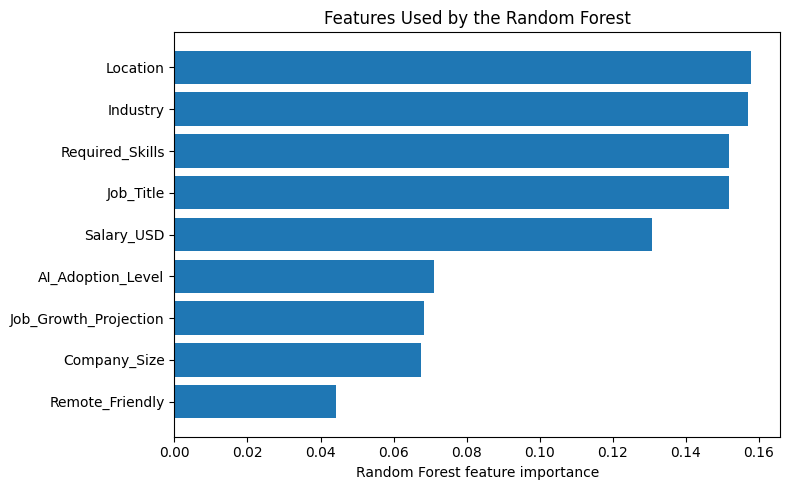

In [58]:
plot_data = aggregated_importance.sort_values(
    "Importance",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    plot_data["Original_Feature"],
    plot_data["Importance"],
)

ax.set_xlabel("Random Forest feature importance")
ax.set_ylabel("")
ax.set_title("Features Used by the Random Forest")

plt.tight_layout()
plt.show()

### 2L.2. Held-out permutation importance

Built-in Random Forest feature importance indicates which variables the trees
used when constructing predictions, but does not establish whether those
variables contribute to successful generalisation.

Permutation importance provides an additional out-of-sample check. Each
original predictor is randomly shuffled in the held-out test set while all
other predictors remain unchanged. The resulting decrease in model performance
measures how much the fitted model depends on that predictor for successful
classification of unseen observations.

Because the overall classifier has weak held-out performance, these values are
interpreted as model diagnostics rather than evidence of real-world drivers of
automation risk.

In [59]:
from sklearn.inspection import permutation_importance

In [60]:
perm_result = permutation_importance(
    random_forest_pipeline,
    X_test,
    y_test,
    scoring="f1_macro",
    n_repeats=30,
    random_state=42,
    n_jobs=-1,
)

In [61]:
permutation_df = pd.DataFrame(
    {
        "Feature": X_test.columns,
        "Permutation_Importance": perm_result.importances_mean,
        "Importance_SD": perm_result.importances_std,
    }
)

permutation_df = permutation_df.sort_values(
    "Permutation_Importance",
    ascending=False,
)

permutation_df.round(3)

,Feature,Permutation_Importance,Importance_SD
6,Salary_USD,0.028,0.027
2,Company_Size,0.021,0.026
1,Industry,-0.005,0.029
0,Job_Title,-0.009,0.040
8,Job_Growth_Projection,-0.010,0.032
3,Location,-0.020,0.036
4,AI_Adoption_Level,-0.021,0.025
7,Remote_Friendly,-0.036,0.021
5,Required_Skills,-0.063,0.036


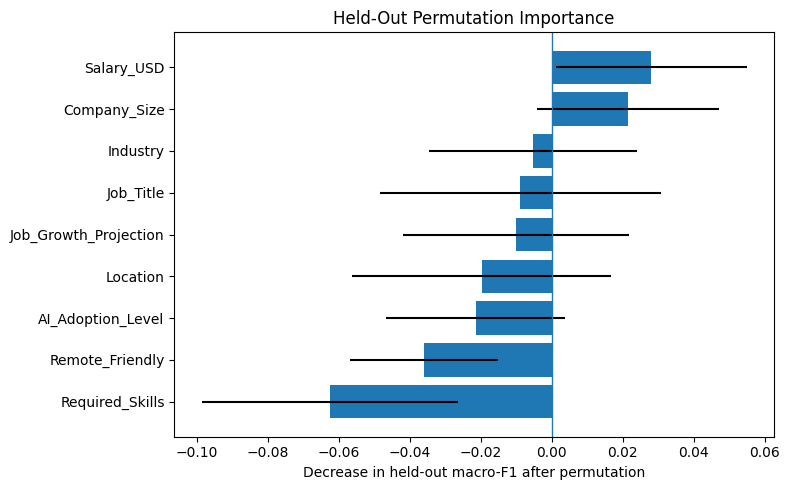

In [62]:
perm_plot = permutation_df.sort_values(
    "Permutation_Importance",
    ascending=True,
)

fig, ax = plt.subplots(figsize=(8, 5))

ax.barh(
    perm_plot["Feature"],
    perm_plot["Permutation_Importance"],
    xerr=perm_plot["Importance_SD"],
)

ax.axvline(0, linewidth=1)

ax.set_xlabel("Decrease in held-out macro-F1 after permutation")
ax.set_ylabel("")
ax.set_title("Held-Out Permutation Importance")

plt.tight_layout()
plt.show()

### Feature-importance interpretation

The Random Forest's built-in impurity importance suggested that variables such
as Location, Industry, Required Skills, and Job Title were used relatively
heavily when constructing the model's decision trees.

However, held-out permutation importance did not confirm that these variables
provided stable predictive information on unseen observations.

Only Salary and Company Size had positive mean permutation importance, and
their effects were small relative to the variability across permutations.
Most other predictors had mean importance close to or below zero. In
particular, shuffling Required Skills improved rather than reduced mean
held-out macro-F1.

The contrast between the two importance methods suggests that the Random
Forest learned patterns in the training data that did not translate into
reliable out-of-sample predictive information.

Accordingly, the built-in feature importances should be interpreted only as
descriptions of how this fitted Random Forest constructed its predictions,
not as evidence that these variables are reliable drivers of automation risk.

## 2M. Consistency with exploratory analysis

The modelling results are consistent with the findings from Stage 1.

Stage 1 found no statistically supported association between the supplied
categorical predictors and `Automation_Risk` after multiple-testing correction,
with effect sizes close to those expected under weak or absent association.
Salary likewise showed little evidence of systematic separation across risk
classes.

Stage 2 tested whether useful predictive structure might nevertheless emerge
when variables were considered jointly or through nonlinear interactions.
Logistic Regression, Random Forest, and XGBoost all remained close to
chance-level accuracy, and the selected Random Forest achieved only 0.350
accuracy and 0.344 macro-F1 on the held-out test set.

Finally, held-out permutation importance provided little evidence that the
features used internally by the Random Forest contributed stable predictive
information on unseen observations.

Taken together, the exploratory, predictive, and interpretability analyses
tell a consistent story: the supplied dataset does not contain sufficient
empirical signal to support reliable prediction of the supplied
`Automation_Risk` labels.

## 2N. Deployment decision

The selected Random Forest achieved a held-out accuracy of **0.350** and
macro-F1 of **0.344**. Its accuracy was therefore approximately at the level
expected from the balanced three-class target and provided little improvement
over the naive baseline.

The confusion matrix and class-level metrics also showed substantial
misclassification across Low, Medium, and High risk categories. In addition,
held-out permutation importance provided little evidence that the predictors
contributed stable out-of-sample predictive information.

For these reasons, the fitted Random Forest is **not considered sufficiently
reliable for deployment as a role-level automation-risk prediction engine**.

The model will therefore be retained as an analytical result demonstrating the
limitations of the supplied dataset, rather than presented to users as a
validated predictor of automation risk.

The final application should distinguish between predictions supported by the
supplied data and decision-support functionality that requires additional
evidence or external enrichment.

## 2O. Preserve modelling artifacts

Stage 2 outputs are preserved for reproducibility and subsequent project
development.

Because held-out validation did not support deployment of the Random Forest as
a reliable automation-risk predictor, the fitted pipeline is saved explicitly
as an **experimental model artifact** rather than as a production or final
prediction model.

The model-comparison and permutation-importance results are also exported so
that subsequent application and reporting stages can use the validated results
without rerunning the modelling notebook.

In [63]:
MODEL_DIR = Path("../models")
PROCESSED_DIR = Path("../data/processed")

MODEL_DIR.mkdir(parents=True, exist_ok=True)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)

In [64]:
comparison_path = PROCESSED_DIR / "model_comparison.csv"

model_comparison.to_csv(
    comparison_path,
    index=False,
)

print(f"Saved: {comparison_path}")

Saved: ..\data\processed\model_comparison.csv


In [65]:
permutation_path = PROCESSED_DIR / "permutation_importance.csv"

permutation_df.to_csv(
    permutation_path,
    index=False,
)

print(f"Saved: {permutation_path}")

Saved: ..\data\processed\permutation_importance.csv


In [66]:
import joblib

In [67]:
model_path = MODEL_DIR / "experimental_random_forest.joblib"

joblib.dump(
    random_forest_pipeline,
    model_path,
)

print(f"Saved: {model_path}")

Saved: ..\models\experimental_random_forest.joblib


In [68]:
artifacts = [
    comparison_path,
    permutation_path,
    model_path,
]

for path in artifacts:
    print(f"{path}: " f"{'OK' if path.exists() else 'MISSING'}")

..\data\processed\model_comparison.csv: OK
..\data\processed\permutation_importance.csv: OK
..\models\experimental_random_forest.joblib: OK


In [69]:
reloaded_rf = joblib.load(model_path)

reloaded_pred = reloaded_rf.predict(X_test)

predictions_match = np.array_equal(
    y_pred,
    reloaded_pred,
)

print(
    "Reloaded model predictions match original:",
    predictions_match,
)

Reloaded model predictions match original: True


## 2P. Modelling conclusions and limitations

### Modelling conclusion

This stage evaluated whether the supplied job-market characteristics could be used to predict the three `Automation_Risk` classes: Low, Medium, and High.

A most-frequent-class dummy classifier was first established as a naive baseline. Three supervised learning approaches of increasing complexity were then evaluated using the same stratified five-fold cross-validation procedure:

- Logistic Regression
- Random Forest
- XGBoost

Random Forest produced the highest mean cross-validated accuracy (**0.368**), compared with **0.360** for Logistic Regression, **0.328** for XGBoost, and **0.345** for the dummy baseline. Logistic Regression and Random Forest both achieved a mean macro-F1 of approximately **0.358**.

The Random Forest was therefore selected for final evaluation because it achieved the highest cross-validated accuracy, although its improvement over the baseline was small.

On the untouched held-out test set, the Random Forest achieved:

- **Accuracy: 0.350**
- **Macro-F1: 0.344**

The confusion matrix and class-level metrics showed substantial misclassification across all three risk categories. The model therefore did not demonstrate reliable separation of Low, Medium, and High automation-risk observations.

Model interpretation produced a similar conclusion. Although built-in Random Forest feature importance showed that several variables were used extensively when constructing the trees, held-out permutation importance provided little evidence that these patterns generalized to unseen observations. Most permutation importances were close to or below zero, and even the positive values were small relative to their variability.

Taken together with the Stage 1 exploratory analysis, these findings indicate that the supplied predictors contain insufficient empirical signal to support a reliable classifier of the supplied `Automation_Risk` labels.

### Limitations

Several limitations affect what can be concluded from this modelling exercise.

**Limited predictive signal.** Stage 1 found little evidence of association between the supplied predictors and `Automation_Risk`, and the supervised models were unable to recover substantial predictive structure when the variables were considered jointly.

**Small dataset.** The dataset contains only **500 observations**. After the train/test split, model development was conducted on an even smaller training sample, limiting the amount of information available for learning and validation.

**Restricted feature set.** The available variables provide broad job-market descriptors but do not contain detailed task-level information, measures of task automatability, AI exposure scores, skill proficiency, occupational transition histories, or longitudinal labour-market information that could plausibly improve displacement-risk modelling.

**Dataset-to-brief mismatch.** Some concepts required by the wider hackathon brief are not directly represented in the supplied data. Consequently, the trained classifier should not be interpreted as measuring all dimensions of AI-driven workforce displacement described in the case study.

**No temporal validation.** The dataset contains no time variable. It is therefore impossible to test whether a model trained on earlier labour-market observations generalizes to later periods or to estimate changes in automation risk over time.

**Feature importance is not causal evidence.** Neither Random Forest impurity importance nor permutation importance establishes that a variable causes automation risk. The importance analyses describe the predictive behaviour of the fitted model only.

**No evidence of deployment-level reliability.** The selected model's held-out performance remained approximately at the level expected for this balanced three-class problem. It should therefore not be presented as a validated role-level automation-risk prediction system.

### Implication for the final solution

The supervised modelling requirement of the hackathon has been implemented and evaluated, but the resulting model will be retained as an **experimental analytical artifact rather than deployed as a validated risk predictor**.

Subsequent stages should therefore preserve the distinction between:

1. **findings directly supported by the supplied dataset;**
2. **quantities that can be derived through transparent feature engineering; and**
3. **decision-support functions that require external evidence or enrichment.**

This allows the final solution to address the broader workforce-transition problem while remaining transparent about what the supplied data can and cannot support.